importar bibliotecas

In [29]:
import yfinance as yf
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

print("Pacotes carregados com sucesso.")

Pacotes carregados com sucesso.


Definir período, índice e ações

In [30]:
# ══════════════════════════════════════════════════════
# PASSO 1: Definir período, índice e lista de ativos
# ══════════════════════════════════════════════════════

# Maio de 2026
DATA_INICIO = "2021-01-01"
DATA_FIM = "2026-05-01"  # yfinance usa a data final como limite aberto

# Índice-alvo: Ibovespa
ticker_idx_ibov = "^BVSP"

# Lista de papéis componentes do IBOVESPA
tickers_ibov = [
    "VALE3.SA", "ITUB4.SA", "PETR4.SA", "PETR3.SA",
    "AXIA3.SA", "BBDC4.SA", "B3SA3.SA", "SBSP3.SA",
    "ITSA4.SA", "BPAC11.SA", "ABEV3.SA", "WEGE3.SA",
    "BBAS3.SA", "EQTL3.SA", "EMBJ3.SA", "ENEV3.SA",
    "RENT3.SA", "PRIO3.SA", "CPLE3.SA", "RDOR3.SA",
    "VBBR3.SA", "UGPA3.SA", "GGBR4.SA", "RADL3.SA",
    "VIVT3.SA", "SUZB3.SA", "BBDC3.SA", "CMIG4.SA",
    "BBSE3.SA", "RAIL3.SA", "TOTS3.SA", "TIMS3.SA",
    "AXIA6.SA", "ENGI11.SA", "MOTV3.SA", "ALOS3.SA",
    "LREN3.SA", "KLBN11.SA", "MBRF3.SA", "ISAE4.SA",
    "ASAI3.SA", "EGIE3.SA", "CSAN3.SA", "SMFT3.SA",
    "CXSE3.SA", "SANB11.SA", "CSMG3.SA", "MULT3.SA",
    "PSSA3.SA", "CPFE3.SA", "NATU3.SA", "TAEE11.SA",
    "GOAU4.SA", "BRAV3.SA", "CMIN3.SA", "HYPE3.SA",
    "FLRY3.SA", "CYRE3.SA", "IGTI11.SA", "BRAP4.SA",
    "COGN3.SA", "CURY3.SA", "CSNA3.SA", "POMO4.SA",
    "USIM5.SA", "AURE3.SA", "DIRR3.SA", "SLCE3.SA",
    "RECV3.SA", "HAPV3.SA", "VIVA3.SA", "YDUQ3.SA",
    "MGLU3.SA", "CEAB3.SA", "MRVE3.SA", "BRKM5.SA",
    "AZZA3.SA", "BEEF3.SA", "VAMO3.SA"
]

print("Período:", DATA_INICIO, "até", DATA_FIM)
print("Índice-alvo:", ticker_idx_ibov)
print("Número de papéis candidatos:", len(tickers_ibov))
print("Número de papéis únicos:", len(set(tickers_ibov)))

Período: 2021-01-01 até 2026-05-01
Índice-alvo: ^BVSP
Número de papéis candidatos: 79
Número de papéis únicos: 79


Baixar dados do índice IBOVESPA

In [31]:
# ══════════════════════════════════════════════════════
# PASSO 2: Baixar os dados
# ══════════════════════════════════════════════════════

print("⬇️ Baixando dados dos ativos do IBOVESPA...")

dados_ibov_raw = yf.download(
    tickers_ibov,
    start=DATA_INICIO,
    end=DATA_FIM,
    auto_adjust=True,
    progress=False,
    group_by="column"
)

print("⬇️ Baixando dados do índice IBOVESPA...")

indice_ibov_raw = yf.download(
    ticker_idx_ibov,
    start=DATA_INICIO,
    end=DATA_FIM,
    auto_adjust=True,
    progress=False
)

print("Download concluído.")

⬇️ Baixando dados dos ativos do IBOVESPA...
⬇️ Baixando dados do índice IBOVESPA...
Download concluído.


Extrair preço de fechamento ajustado

In [32]:
# ══════════════════════════════════════════════════════
# PASSO 3: Extrair preços ajustados
# ══════════════════════════════════════════════════════
# Com auto_adjust=True, a coluna Close já vem ajustada.
# Isso equivale ao uso do Adj Close para análise histórica.

# ------------------------------
# Ativos do IBOVESPA
# ------------------------------

if isinstance(dados_ibov_raw.columns, pd.MultiIndex):
    dados_ibov = dados_ibov_raw["Close"].copy()
else:
    dados_ibov = dados_ibov_raw[["Close"]].copy()
    dados_ibov.columns = tickers_ibov

# Remover ativos completamente vazios
dados_ibov = dados_ibov.dropna(axis=1, how="all")

# ------------------------------
# Índice IBOVESPA
# ------------------------------

indice_ibov = indice_ibov_raw["Close"].copy()

# Em alguns casos, yfinance retorna DataFrame mesmo para um único ticker
if isinstance(indice_ibov, pd.DataFrame):
    indice_ibov = indice_ibov.iloc[:, 0]

indice_ibov.name = "IBOVESPA"

# ------------------------------
# Verificação rápida
# ------------------------------

print(f"✅ IBOV: {dados_ibov.shape[1]} ativos × {dados_ibov.shape[0]} pregões")
print(f"✅ Índice IBOVESPA: {indice_ibov.shape[0]} pregões")

print("\nPeríodo dos ativos:")
print(dados_ibov.index.min().date(), "→", dados_ibov.index.max().date())

print("\nPeríodo do índice:")
print(indice_ibov.index.min().date(), "→", indice_ibov.index.max().date())

print("\nPrimeiras linhas dos preços dos ativos:")
display(dados_ibov.head())

print("\nPrimeiras linhas do índice:")
display(indice_ibov.head())

✅ IBOV: 79 ativos × 1327 pregões
✅ Índice IBOVESPA: 1327 pregões

Período dos ativos:
2021-01-04 → 2026-04-30

Período do índice:
2021-01-04 → 2026-04-30

Primeiras linhas dos preços dos ativos:


Ticker,ABEV3.SA,ALOS3.SA,ASAI3.SA,AURE3.SA,AXIA3.SA,AXIA6.SA,AZZA3.SA,B3SA3.SA,BBAS3.SA,BBDC3.SA,...,TOTS3.SA,UGPA3.SA,USIM5.SA,VALE3.SA,VAMO3.SA,VBBR3.SA,VIVA3.SA,VIVT3.SA,WEGE3.SA,YDUQ3.SA
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,11.909067,22.886629,NaN,NaN,28.400923,18.956636,56.326679,16.629671,12.455722,13.288727,...,25.773197,8.949858,12.068115,52.859421,NaN,14.553741,25.622471,16.814665,33.141602,29.567636
2021-01-05,12.162944,22.878506,NaN,NaN,27.667585,18.412027,55.465210,16.662397,12.326492,13.225186,...,25.652502,8.875647,12.197358,53.749462,NaN,14.720259,24.423811,16.671926,35.175751,29.715473
2021-01-06,12.409125,21.741484,NaN,NaN,27.221205,18.307295,52.185013,16.389692,12.608143,13.557653,...,24.436256,8.768040,12.787031,55.512226,NaN,14.507116,23.684790,16.485252,36.108452,28.532770
2021-01-07,12.347579,21.270430,NaN,NaN,27.029896,17.961676,52.118748,16.847839,13.108496,13.890112,...,24.371271,9.035200,13.400940,59.135967,NaN,14.773545,23.720835,16.068007,37.600754,28.889324
2021-01-08,12.716853,22.050102,NaN,NaN,27.882799,18.485336,53.096184,17.096006,13.184708,13.783048,...,25.996023,9.268966,13.336319,58.951046,NaN,15.186509,23.883062,16.488924,39.874737,29.872009



Primeiras linhas do índice:


Date
2021-01-04    118558.0
2021-01-05    119223.0
2021-01-06    119851.0
2021-01-07    121956.0
2021-01-08    125077.0
Name: IBOVESPA, dtype: float64

Verificar faltantes

In [33]:
# ══════════════════════════════════════════════════════
# PASSO 4: Verificar quais ativos foram baixados
# ══════════════════════════════════════════════════════

ativos_esperados = set(tickers_ibov)
ativos_baixados = set(dados_ibov.columns)

ativos_faltantes = sorted(ativos_esperados - ativos_baixados)

print("Ativos esperados:", len(ativos_esperados))
print("Ativos baixados:", len(ativos_baixados))
print("Ativos faltantes:", len(ativos_faltantes))

if len(ativos_faltantes) > 0:
    print("\nAtivos faltantes ou sem dados no Yahoo Finance:")
    print(ativos_faltantes)
else:
    print("\nTodos os ativos foram baixados.")

Ativos esperados: 79
Ativos baixados: 79
Ativos faltantes: 0

Todos os ativos foram baixados.


Salvar preços baixados

In [35]:
# ══════════════════════════════════════════════════════
# PASSO 5: Salvar os preços localmente
# ══════════════════════════════════════════════════════

dados_ibov.to_csv("ibov_precos.csv", encoding="utf-8-sig")
indice_ibov.to_csv("ibov_indice.csv", encoding="utf-8-sig")

print("Arquivos de preços salvos:")
print("- ibov_precos.csv")
print("- ibov_indice.csv")

Arquivos de preços salvos:
- ibov_precos.csv
- ibov_indice.csv


Calcular retorno logaritmico

In [36]:
# ══════════════════════════════════════════════════════
# PASSO 6: Calcular retornos logarítmicos
# ══════════════════════════════════════════════════════
# Retorno logarítmico diário:
# r_t = ln(P_t / P_t-1)

ret_ibov = np.log(dados_ibov / dados_ibov.shift(1)).dropna(how="all")
ret_idx_ib = np.log(indice_ibov / indice_ibov.shift(1)).dropna()

ret_idx_ib.name = "Retorno_IBOV"

print("Formato dos retornos dos ativos IBOV:", ret_ibov.shape)
print("Formato dos retornos do índice IBOV:", ret_idx_ib.shape)

print(f"\nRetorno médio diário do IBOV: {ret_idx_ib.mean():.4%}")
print(f"Volatilidade diária do IBOV: {ret_idx_ib.std():.4%}")

print("\nPrimeiras linhas dos retornos dos ativos:")
display(ret_ibov.head())

print("\nPrimeiras linhas do retorno do índice:")
display(ret_idx_ib.head())

Formato dos retornos dos ativos IBOV: (1326, 79)
Formato dos retornos do índice IBOV: (1326,)

Retorno médio diário do IBOV: 0.0345%
Volatilidade diária do IBOV: 1.1317%

Primeiras linhas dos retornos dos ativos:


Ticker,ABEV3.SA,ALOS3.SA,ASAI3.SA,AURE3.SA,AXIA3.SA,AXIA6.SA,AZZA3.SA,B3SA3.SA,BBAS3.SA,BBDC3.SA,...,TOTS3.SA,UGPA3.SA,USIM5.SA,VALE3.SA,VAMO3.SA,VBBR3.SA,VIVA3.SA,VIVT3.SA,WEGE3.SA,YDUQ3.SA
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.021094,-0.000355,NaN,NaN,-0.026160,-0.029150,-0.015412,0.001966,-0.010429,-0.004793,...,-0.004694,-0.008326,0.010653,0.016698,NaN,0.011377,-0.047911,-0.008525,0.059568,0.004987
2021-01-06,0.020038,-0.050976,NaN,NaN,-0.016265,-0.005705,-0.060961,-0.016502,0.022592,0.024828,...,-0.048573,-0.012198,0.047212,0.032270,NaN,-0.014585,-0.030725,-0.011260,0.026170,-0.040615
2021-01-07,-0.004972,-0.021904,NaN,NaN,-0.007053,-0.019059,-0.001271,0.027570,0.038918,0.024226,...,-0.002663,0.030015,0.046893,0.063236,NaN,0.018199,0.001521,-0.025636,0.040497,0.012419
2021-01-08,0.029468,0.035999,NaN,NaN,0.031066,0.028737,0.018580,0.014622,0.005797,-0.007738,...,0.064539,0.025544,-0.004834,-0.003132,NaN,0.027569,0.006816,0.025859,0.058719,0.033450
2021-01-11,-0.026358,-0.044050,NaN,NaN,-0.036982,-0.022054,-0.015724,-0.042026,-0.016470,-0.015243,...,-0.001787,-0.047970,0.012041,-0.000196,NaN,-0.020382,-0.031043,-0.011386,-0.031109,-0.052597



Primeiras linhas do retorno do índice:


Date
2021-01-05    0.005593
2021-01-06    0.005254
2021-01-07    0.017411
2021-01-08    0.025269
2021-01-11   -0.018316
Name: Retorno_IBOV, dtype: float64

Retorno simples percentual

In [37]:
# ══════════════════════════════════════════════════════
# PASSO EXTRA: Calcular retornos simples percentuais
# ══════════════════════════════════════════════════════
# Retorno simples diário:
# r_t = (P_t / P_t-1) - 1
#
# Esse é o retorno usado na formulação do artigo-base:
# retorno = preço_t / preço_t-1 - 1

ret_ibov_simples = dados_ibov.pct_change().dropna(how="all")
ret_idx_ib_simples = indice_ibov.pct_change().dropna()

ret_idx_ib_simples.name = "Retorno_IBOV_Simples"

print("Formato dos retornos simples dos ativos IBOV:", ret_ibov_simples.shape)
print("Formato dos retornos simples do índice IBOV:", ret_idx_ib_simples.shape)

print(f"\nRetorno médio diário simples do IBOV: {ret_idx_ib_simples.mean():.4%}")
print(f"Volatilidade diária simples do IBOV: {ret_idx_ib_simples.std():.4%}")

print("\nPrimeiras linhas dos retornos simples dos ativos:")
display(ret_ibov_simples.head())

print("\nPrimeiras linhas do retorno simples do índice:")
display(ret_idx_ib_simples.head())

# Salvar retornos simples
ret_ibov_simples.to_csv("ibov_retornos_simples.csv", encoding="utf-8-sig")
ret_idx_ib_simples.to_csv("ibov_indice_retornos_simples.csv", encoding="utf-8-sig")

print("\nArquivos de retornos simples salvos:")
print("- ibov_retornos_simples.csv")
print("- ibov_indice_retornos_simples.csv")

Formato dos retornos simples dos ativos IBOV: (1326, 79)
Formato dos retornos simples do índice IBOV: (1326,)

Retorno médio diário simples do IBOV: 0.0409%
Volatilidade diária simples do IBOV: 1.1308%

Primeiras linhas dos retornos simples dos ativos:


Ticker,ABEV3.SA,ALOS3.SA,ASAI3.SA,AURE3.SA,AXIA3.SA,AXIA6.SA,AZZA3.SA,B3SA3.SA,BBAS3.SA,BBDC3.SA,...,TOTS3.SA,UGPA3.SA,USIM5.SA,VALE3.SA,VAMO3.SA,VBBR3.SA,VIVA3.SA,VIVT3.SA,WEGE3.SA,YDUQ3.SA
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.021318,-0.000355,NaN,NaN,-0.025821,-0.028729,-0.015294,0.001968,-0.010375,-0.004782,...,-0.004683,-0.008292,0.010709,0.016838,NaN,0.011442,-0.046782,-0.008489,0.061378,0.005000
2021-01-06,0.020240,-0.049698,NaN,NaN,-0.016134,-0.005688,-0.059140,-0.016366,0.022849,0.025139,...,-0.047412,-0.012124,0.048344,0.032796,NaN,-0.014480,-0.030258,-0.011197,0.026515,-0.039801
2021-01-07,-0.004960,-0.021666,NaN,NaN,-0.007028,-0.018879,-0.001270,0.027953,0.039685,0.024522,...,-0.002659,0.030470,0.048010,0.065278,NaN,0.018365,0.001522,-0.025310,0.041328,0.012496
2021-01-08,0.029907,0.036655,NaN,NaN,0.031554,0.029154,0.018754,0.014730,0.005814,-0.007708,...,0.066667,0.025873,-0.004822,-0.003127,NaN,0.027953,0.006839,0.026196,0.060477,0.034016
2021-01-11,-0.026013,-0.043094,NaN,NaN,-0.036306,-0.021813,-0.015601,-0.041155,-0.016336,-0.015127,...,-0.001786,-0.046837,0.012114,-0.000196,NaN,-0.020175,-0.030566,-0.011321,-0.030630,-0.051237



Primeiras linhas do retorno simples do índice:


Date
2021-01-05    0.005609
2021-01-06    0.005267
2021-01-07    0.017563
2021-01-08    0.025591
2021-01-11   -0.018149
Name: Retorno_IBOV_Simples, dtype: float64


Arquivos de retornos simples salvos:
- ibov_retornos_simples.csv
- ibov_indice_retornos_simples.csv


Salvar retorno

In [38]:
# ══════════════════════════════════════════════════════
# PASSO 7: Salvar retornos
# ══════════════════════════════════════════════════════

ret_ibov.to_csv("ibov_retornos.csv", encoding="utf-8-sig")
ret_idx_ib.to_csv("ibov_indice_retornos.csv", encoding="utf-8-sig")

print("Arquivos de retornos salvos:")
print("- ibov_retornos.csv")
print("- ibov_indice_retornos.csv")

Arquivos de retornos salvos:
- ibov_retornos.csv
- ibov_indice_retornos.csv


In [55]:
display(indice_ibov)

Data
2021-01-04    118558.0
2021-01-05    119223.0
2021-01-06    119851.0
2021-01-07    121956.0
2021-01-08    125077.0
                ...   
2026-04-24    190745.0
2026-04-27    189579.0
2026-04-28    188619.0
2026-04-29    184750.0
2026-04-30    187318.0
Name: IBOVESPA, Length: 1327, dtype: float64

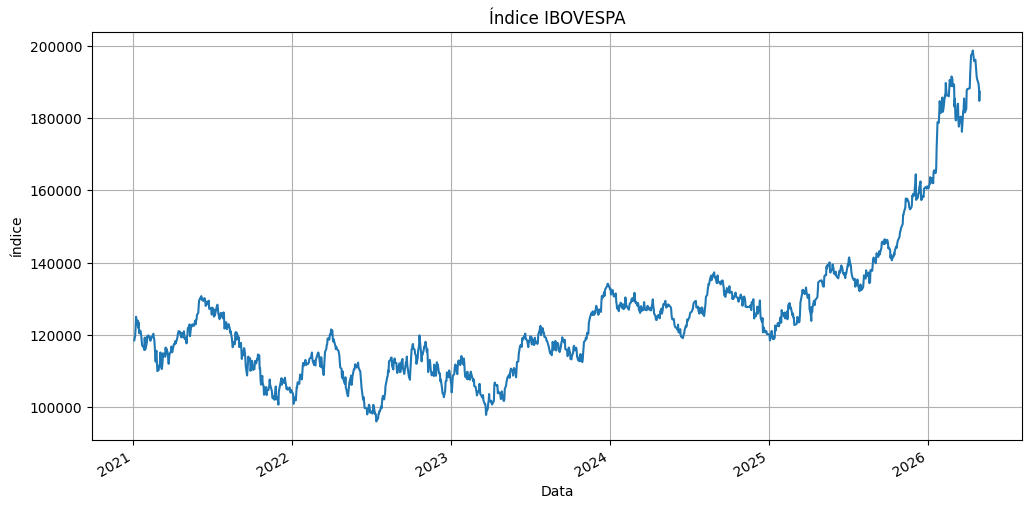

In [58]:
import matplotlib.pyplot as plt

indice_ibov.plot(figsize=(12, 6), title="Índice IBOVESPA")

# Adiciona rótulos e grade para facilitar a leitura
plt.xlabel("Data")
plt.ylabel("índice")
plt.grid(True)

# Exibe o gráfico
plt.show()